# Projet de Fairness : Analyse et réduction des biais du modèle `RESNET18` 

> Arthur LE GAL

> Carlos CLEMENT

> Leonor MARTIN NOURRY

## I. Introduction

Ce projet, basé sur le dataset `NIH Chest X-rays` , a pour objectif d'entraîner un modèle de Deep Learning (`ResNet18`) à détecter des pathologies pulmonaires à partir de radiographies.  
Cependant, ce type d'algorithme a tendance à apprendre et amplifier les biais présents dans les données médicales. Ce rapport consiste donc à détecter puis à mitiger ces biais.  
Pour la détection, nous procéderons à une analyse rapide du jeu de données (`metadata.csv`), puis nous confirmerons nos hypothèses en évaluant les prédictions brutes du modèle.  
Pour la correction, nous appliquerons différentes méthodes (pre-processing, post-processing et leur combinaison) afin de déterminer laquelle offre au modèle le meilleur compromis entre équité et performance.

## II. Analyse rapide des données

Dans cette partie, on va procéder à une analyse rapide des données, en réutilisant la même méthode que pour le mi-projet.
On va donc détecter les déséquilibres dans les données via une analyse univariée, puis identifier les biais factuels présents dans le jeu de données, qui seront les mêmes que l'on a identifié lors du mi-projet (normalement).

---

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# On charge le dataset
df = pd.read_csv('DATA/metadata.csv')

# Création d'une colonne numérique pour faciliter les calculs
df['is_malade'] = (df['label'] == 'malade').astype(int)

# Création des tranches d'âge 
df['Age Group'] = pd.cut(df['Patient Age'], bins=[0, 39, 60, 120], labels=['<40 ans', '40-60 ans', '>60 ans'])

# On affiche les déséquilibres (Analyse Univariée)
print("Répartition par Position de vue ")
print(df['View Position'].value_counts(normalize=True) * 100)

print("\nRépartition par Genre ")
print(df['Patient Gender'].value_counts(normalize=True) * 100)

print("\nRépartition par Âge ")
print(df['Age Group'].value_counts(normalize=True) * 100)

# Puis on idetifie les biais (Analyse Bivariée)
print("\nTaux de maladie par Position de vue ")
biais_pos = df.groupby('View Position')['is_malade'].mean() * 100
print(biais_pos)

print("\nTaux de maladie par Genre ")
biais_genre = df.groupby('Patient Gender')['is_malade'].mean() * 100
print(biais_genre)

print("\nTaux de maladie par Âge ")
print(df.groupby('Age Group')['is_malade'].mean() * 100)

# Graphique
fig = px.bar(biais_pos, 
             title="Biais de position : Différence du taux de maladie selon la position (AP vs PA)",
             labels={'value': '% de patients malades', 'View Position': 'Position de la radiographie'},
             text_auto='.1f',
             color=biais_pos.index)
fig.show()

Répartition par Position de vue 
View Position
PA    57.588246
AP    42.411754
Name: proportion, dtype: float64

Répartition par Genre 
Patient Gender
M    63.124888
F    36.875112
Name: proportion, dtype: float64

Répartition par Âge 
Age Group
40-60 ans    49.551971
<40 ans      31.111111
>60 ans      19.336918
Name: proportion, dtype: float64

Taux de maladie par Position de vue 
View Position
AP    54.034643
PA    42.906036
Name: is_malade, dtype: float64

Taux de maladie par Genre 
Patient Gender
F    45.869776
M    48.651717
Name: is_malade, dtype: float64

Taux de maladie par Âge 
Age Group
<40 ans      42.281106
40-60 ans    47.884268
>60 ans      55.514365
Name: is_malade, dtype: float64


/var/folders/w9/w_p3jqm55fx10_s1f_my5klw0000gn/T/ipykernel_3076/2148963141.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age Group')['is_malade'].mean() * 100)


In [3]:
df['Patient Age'].describe()

count    5581.000000
mean       46.660276
std        17.170920
min         1.000000
25%        35.000000
50%        49.000000
75%        59.000000
max       412.000000
Name: Patient Age, dtype: float64

Une vérification rapide de la qualité des données révèle une valeur aberrante (un patient de 412 ans). Cependant, ce projet se concentrant sur les biais d'images, cette aberration a simplement été absorbée par la catégorie '> 60 ans' lors de notre audit, sans impacter l'entraînement du modèle (qui s'entraîne sur des images).

---

L'analyse univariée révèle de nets déséquilibres démographiques, notamment sur le genre (environ **63%** d'hommes pour **37%** de femmes) et sur l'âge (majorité de patients entre **40** et **60** ans).  
L'analyse bivariée montre que les biais de diagnostic associés au genre et à l'âge restent modérés (leurs scores de *Disparate Impact* respectant les seuils de tolérance). En revanche, elle met en évidence un biais factuel majeur sur la modalité de prise de vue : 54% des patients radiographiés en position couchée (AP) sont étiquetés malades, contre seulement **43%** pour ceux en position debout (PA). Cela représente un *Disparate Impact* de **0.79**, franchissant ainsi le seuil critique d'équité des **80%**. Ce biais statistique dans nos données risque donc fortement d'être utilisé comme un raccourci par le réseau de neurones lors de son apprentissage.

---

## III. Modèle de base (Baseline)

Dans cette partie nous allons procéder à l'entraînement "brut" du modèle sur nos données, afin de constater l'étendue des dégâts. Autrement dit, on va vouloir confirmer que le modèle a effectivement amplifié les biais initialement présents dans notre jeu de données.  
Pour ce faire, nous évaluerons ses prédictions en calculant sa performance globale (*Balanced Accuracy*) ainsi que ses métriques d'équité (*Disparate Impact* ou *Statistical Parity Difference*).  
Ces résultats constitueront notre point de référence pour mesurer l'efficacité de nos futures méthodes de correction.

---

Nous avons donc à cette étape entraîner le modèle sur nos données (images + `metadata.csv`) avec la commande :   
`uv run python train_classifieur.py --logdir expe_log_baseline/ --datadir DATA/ --csv DATA/metadata.csv --csv_out expe_log_baseline/preds_baseline.csv`  
Les résultats annoncent une *balanced accuracy* sans poids de **0.7205338321148248**, soit environ **72%**.  
Aussi, nous avons mis nos prédictions dans le fichier `preds_baseline.csv`, que l'on va maintenant analyser pour le calcul du *Disparate Impact* du modèle à cette étape (entraînement brut sans corrections).

---

In [4]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# On charge le fichier contenant les prédictions
df_preds = pd.read_csv("expe_log_baseline/preds_baseline.csv")


# Puis on convertit les chaînes 'malade'/'sain' en 1 et 0 pour les calculs
df_preds['y_true'] = (df_preds['labels'] == 'malade').astype(int)
df_preds['y_pred'] = (df_preds['preds'] == 'malade').astype(int)

# On recalcule la balanced accuracy pour s'assurer que c'est bien environ 0.72
acc = accuracy_score(df_preds['y_true'], df_preds['y_pred'])
bal_acc = balanced_accuracy_score(df_preds['y_true'], df_preds['y_pred'])

print("PERFORMANCES DU MODÈLE DE BASE ")
print(f"Accuracy (Précision globale)   : {acc:.4f}")
print(f"Balanced Accuracy (Équilibrée) : {bal_acc:.4f}")

# Calcul du Disparate Impact
stats_preds = df_preds.groupby('View Position')['y_pred'].mean()
di_baseline = stats_preds['PA'] / stats_preds['AP']

print("\nÉVALUATION DES BIAIS")
print(f"Taux de prédiction 'Malade' (AP) : {stats_preds['AP']*100:.1f}%")
print(f"Taux de prédiction 'Malade' (PA) : {stats_preds['PA']*100:.1f}%")
print(f"Disparate Impact de la Baseline  : {di_baseline:.4f}")

# Graphique de l'amplification du biais
fig = px.bar(stats_preds, 
             title="Amplification du biais par la Baseline : Prédictions du modèle (AP vs PA)",
             labels={'value': '% prédit malade', 'View Position': 'Position'},
             text_auto='.1f',
             color=stats_preds.index)
fig.show()

PERFORMANCES DU MODÈLE DE BASE 
Accuracy (Précision globale)   : 0.7216
Balanced Accuracy (Équilibrée) : 0.7205

ÉVALUATION DES BIAIS
Taux de prédiction 'Malade' (AP) : 60.0%
Taux de prédiction 'Malade' (PA) : 37.1%
Disparate Impact de la Baseline  : 0.6182


L'évaluation de notre modèle de base confirme nos craintes. Le modèle a non seulement appris le raccourci lié à la position de vue, mais il l'a considérablement amplifié. Alors que l'écart initial dans les données était de 11 points, le modèle crée un écart de 23 points (60% de prédictions 'malade' en AP contre 37% en PA). Le score de *Disparate Impact* tombe à **0.618**, ce qui est critique (largement inférieur au seuil acceptable de **0.80**).  
On va donc appliquer des méthodes de mitigation de biais pour corriger le modèle.

---

## IV. Méthode 1 : Pre-processing

**Note sur le choix des algorithmes de Pre-processing**: Bien que la librairie `AIF360` propose d'autres méthodes comme le `Disparate Impact Remover`, cette dernière modifie directement la valeur des features. Dans le cadre d'un modèle de Computer Vision comme `ResNet18` traitant des images radiographiques complexes, modifier les pixels d'entrée risquerait de détruire le signal médical. C'est pourquoi nous avons privilégié des méthodes basées sur la modification des poids d'échantillonnage comme le `Reweighing` et `compute_sample_weight`, qui préservent l'intégrité de l'image d'origine.

---

Dans cette partie, on va dans un premier temps appliquer des algorithmes de pre-processing à nos données. En particulier, on va utiliser les méthodes de pondération suivantes : `Reweighing` de la librairie `AIF360` (cf Mi-projet) et la fonction `compute_sample_weight` de la librairie `Scikit-Learn`.

Ensuite, on ajoutera ces poids à notre jeu de données puis on entraînera le modèle sur ce même jeu de données modifié.

Après avoir entraîné notre modèle avec notre dataset modifié, on cherchera à mesurer l'impact que ce pre-processing aura eu sur les performances du modèle. C'est à dire que maintenant que le modèle a été "corrigé" une première fois, est-ce qu'il fonctionne encore, et est-ce que les biais ont été réduits (du moins partiellement) ? \
Pour vérifier la performance, on utilisera la *balanced accuracy* et la *matrice de confusion*.  
Pour vérifier la réduction des biais, on utilisera les métriques de `AIF360` usuelles.

On récupérera aussi les prédictions de notre modèle sous la forme de fichiers `preds_***.csv`. Cela nous sera utile pour le post-processing.

### Méthode de pondération 1 : *Reweighing* de `AIF360`
--- 
L'objectif est de forcer le modèle à accorder plus d'importance aux groupes défavorisés (ex: les patients sains en position AP) et moins d'importance aux groupes privilégiés (ex: les patients sains en position PA).  
Nous allons donc calculer ces poids (`WEIGHTS`) avec `AIF360`, les sauvegarder dans un nouveau fichier `metadata_poids_rw.csv`, puis forcer notre modèle ResNet18 à s'entraîner en lisant cette nouvelle colonne de règles.

---

In [5]:
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing

# On charge les données "brutes"
df = pd.read_csv("DATA/metadata.csv")

# Puis on prépare les colonnes au format AIF360 (format numérique)
df['is_malade'] = (df['label'] == 'malade').astype(int)
df['is_PA'] = (df['View Position'] == 'PA').astype(int)

# On crée l'objet AIF360
dataset = StandardDataset(
    df=df,
    label_name='is_malade',
    favorable_classes=[0], # Favorable = être sain (0)
    protected_attribute_names=['is_PA'],
    privileged_classes=[[1]], # Privilégié = position PA (1)
    features_to_keep=['is_PA']
)

# On appplique le Reweighing
RW = Reweighing(unprivileged_groups=[{'is_PA': 0}], privileged_groups=[{'is_PA': 1}])
dataset_transf = RW.fit_transform(dataset)

# Enfin, on récupère les poids et on les sauvegarde dans le nouveau fichier metadata_poids_rw.csv
df['WEIGHTS'] = dataset_transf.instance_weights
df.to_csv("DATA/metadata_poids_rw.csv", index=False)

print(df[['View Position', 'label', 'WEIGHTS']].head(5))

  View Position   label   WEIGHTS
0            PA  malade  1.110004
1            PA    sain  0.917332
2            PA  malade  1.110004
3            PA    sain  0.917332
4            PA    sain  0.917332


/Users/arthur/TD_bias_mitigation/.venv/lib/python3.12/site-packages/inFairness/utils/ndcg.py:37: FutureWarning:

We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html

/Users/arthur/TD_bias_mitigation/.venv/lib/python3.12/site-packages/inFairness/utils/ndcg.py:48: FutureWarning:

We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html



Maintenant, on entraîne le modèle avec le fichier `metadata_poids_rw.csv` à l'aide de la commande :  
`uv run python train_classifieur.py \
  --logdir expe_log_reweighing/ \
  --datadir DATA/ \
  --csv DATA/metadata_poids_rw.csv \
  --weights_col WEIGHTS \
  --csv_out expe_log_reweighing/preds_reweighing.csv`

---
Une fois l'entraînement terminé, on peut passer aux calculs du *Disparate Impact*, de la *Statistical Parity Difference*, de la *Balanced accuracy* et de la *matrice de confusion*.

---

RÉSULTATS PERFORMANCES (REWEIGHING)
Balanced Accuracy : 0.6744 


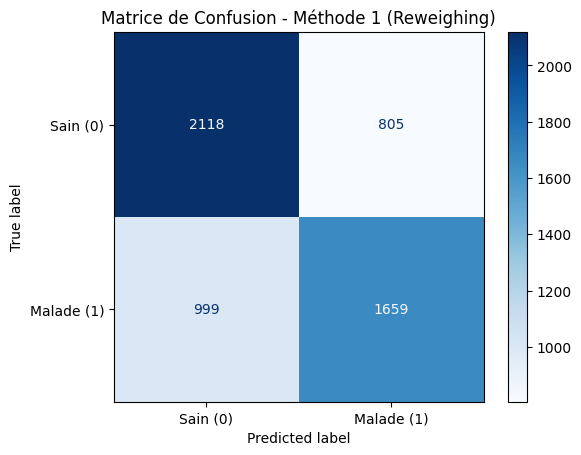


RÉSULTATS FAIRNESS (REWEIGHING)
Taux prédiction 'Malade' AP : 51.0%
Taux prédiction 'Malade' PA : 39.1%
Disparate Impact (DI)  : 0.7670 (Idéal = 1.0, Seuil critique < 0.8)
Statistical Parity (SPD) : 0.1188 (Idéal = 0.0, Seuil critique > 0.1)


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# On charge les nouvelles prédictions
df_preds = pd.read_csv("expe_log_reweighing/preds_reweighing.csv")

# Puis on prépare les données (1 = malade, 0 = sain)
df_preds['y_true'] = (df_preds['labels'] == 'malade').astype(int)
df_preds['y_pred'] = (df_preds['preds'] == 'malade').astype(int)

# Performance du modèle

bal_acc = balanced_accuracy_score(df_preds['y_true'], df_preds['y_pred'])
cm = confusion_matrix(df_preds['y_true'], df_preds['y_pred'])

print("RÉSULTATS PERFORMANCES (REWEIGHING)")
print(f"Balanced Accuracy : {bal_acc:.4f} ")

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sain (0)', 'Malade (1)'])
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion - Méthode 1 (Reweighing)")
plt.show()


# Métrique de Fairness

stats_preds = df_preds.groupby('View Position')['y_pred'].mean()

# Calcul du Disparate Impact 
di = stats_preds['PA'] / stats_preds['AP']

# Calcul de la SPD
spd = abs(stats_preds['PA'] - stats_preds['AP'])

print("\nRÉSULTATS FAIRNESS (REWEIGHING)")
print(f"Taux prédiction 'Malade' AP : {stats_preds['AP']*100:.1f}%")
print(f"Taux prédiction 'Malade' PA : {stats_preds['PA']*100:.1f}%")
print(f"Disparate Impact (DI)  : {di:.4f} (Idéal = 1.0, Seuil critique < 0.8)")
print(f"Statistical Parity (SPD) : {spd:.4f} (Idéal = 0.0, Seuil critique > 0.1)")

---
Bien que le modèle corrigé par `Reweighing` fasse beaucoup de fausses alertes (**1659** Faux Positifs), son nombre de Faux Négatifs (**999** patients malades non détectés) reste le point le plus critique à surveiller pour une application médicale.

L'évaluation de notre modèle corrigé par `Reweighing` montre une baisse de la *Balanced Accuracy* (passant de **72%** à **67.4%**).  
  
Concernant les biais, la correction est visible : le *Disparate Impact* remonte à **0.767** et la *Statistical Parity Difference* se réduit à **0.1188**. Le modèle est donc moins performant, mais beaucoup plus juste. Néanmoins cela reste insuffisant.

---

### Méthode de pondération 2 : Pondération par équilibrage de classes avec `Scikit-Learn`
---
On va maintenant utiliser la fonction `compute_sample_weight` de la librairie `scikit-learn`, qui est une approche statistique classique. Elle attribue un poids inversement proportionnel à la fréquence d'une classe.  
Pour corriger notre biais, on va créer des sous-groupes croisant la position et le diagnostic (ex: AP_malade, PA_sain).  
`Scikit-learn` va générer des poids pour que ces 4 catégories aient le même impact lors de l'apprentissage. Nous sauvegarderons ces règles dans un fichier `metadata_poids_sl.csv`.

---

In [7]:
from sklearn.utils.class_weight import compute_sample_weight

# On charge encore les données brutes 
df = pd.read_csv("DATA/metadata.csv")

# On crée une colonne combinée pour nos 4 sous-groupes
# Cela va créer des étiquettes du style "PA_malade", "AP_sain", "PA_sain" et "AP_malade"
df['Sous_Groupe'] = df['View Position'] + "_" + df['label']

# On calcule les poids avec scikit-learn
# Le paramètre "balanced" donne plus de poids aux groupes rares et moins aux groupes fréquents
poids = compute_sample_weight(class_weight='balanced', y=df['Sous_Groupe'])

# Enfin, on ajoute les poids au dataframe et on met tout dans un fichier .csv
df['WEIGHTS'] = poids
df.to_csv("DATA/metadata_poids_sl.csv", index=False)

print(df[['View Position', 'label', 'Sous_Groupe', 'WEIGHTS']].head(5))

  View Position   label Sous_Groupe   WEIGHTS
0            PA  malade   PA_malade  1.011784
1            PA    sain     PA_sain  0.760354
2            PA  malade   PA_malade  1.011784
3            PA    sain     PA_sain  0.760354
4            PA    sain     PA_sain  0.760354


Maintenant, on entraîne le modèle avec le fichier `metadata_poids_sl.csv` à l'aide de la commande :  
`uv run python train_classifieur.py \
  --logdir expe_log_sklearn/ \
  --datadir DATA/ \
  --csv DATA/metadata_poids_sl.csv \
  --weights_col WEIGHTS \
  --csv_out expe_log_sklearn/preds_sklearn.csv`

---
Une fois l'entraînement terminé, on peut passer aux calculs du *Disparate Impact*, de la *Statistical Parity Difference*, de la *Balanced accuracy* et de la *matrice de confusion*.

---

RÉSULTATS PERFORMANCES (Méthode avec Sklearn) 
Balanced Accuracy : 0.6777 


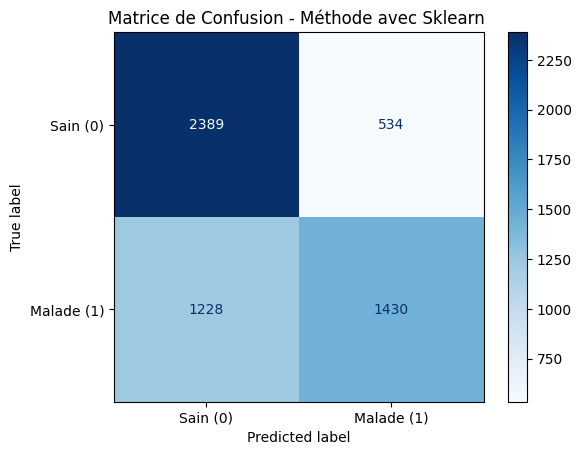


RÉSULTATS FAIRNESS (Méthode avec Sklearn)
Taux prédiction 'Malade' AP : 45.2%
Taux prédiction 'Malade' PA : 27.8%
Disparate Impact (DI)  : 0.6141 (Idéal = 1.0, Seuil critique < 0.8)
Statistical Parity (SPD) : 0.1746 (Idéal = 0.0, Seuil critique > 0.1)


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# On charge les nouvelles prédictions
df_preds = pd.read_csv("expe_log_sklearn/preds_sklearn.csv")

# Puis on prépare les données (1 = malade, 0 = sain)
df_preds['y_true'] = (df_preds['labels'] == 'malade').astype(int)
df_preds['y_pred'] = (df_preds['preds'] == 'malade').astype(int)

# Performance du modèle

bal_acc = balanced_accuracy_score(df_preds['y_true'], df_preds['y_pred'])
cm = confusion_matrix(df_preds['y_true'], df_preds['y_pred'])

print("RÉSULTATS PERFORMANCES (Méthode avec Sklearn) ")
print(f"Balanced Accuracy : {bal_acc:.4f} ")

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sain (0)', 'Malade (1)'])
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion - Méthode avec Sklearn ")
plt.show()


# Métrique de Fairness

stats_preds = df_preds.groupby('View Position')['y_pred'].mean()

# Calcul du Disparate Impact 
di = stats_preds['PA'] / stats_preds['AP']

# Calcul de la SPD
spd = abs(stats_preds['PA'] - stats_preds['AP'])

print("\nRÉSULTATS FAIRNESS (Méthode avec Sklearn)")
print(f"Taux prédiction 'Malade' AP : {stats_preds['AP']*100:.1f}%")
print(f"Taux prédiction 'Malade' PA : {stats_preds['PA']*100:.1f}%")
print(f"Disparate Impact (DI)  : {di:.4f} (Idéal = 1.0, Seuil critique < 0.8)")
print(f"Statistical Parity (SPD) : {spd:.4f} (Idéal = 0.0, Seuil critique > 0.1)")

Au niveau de la performance du modèle, on peut dire rien qu'en observant la matrice de confusion que cette méthode est inefficace. En effet, on a maintenant 1228 Faux Négatifs (contre 999 avec `Reweighing`).  

---
Contrairement à nos espérances, l'équilibrage des classes croisées avec `scikit-learn` s'est révélé inefficace pour corriger le biais de notre modèle.

Bien que la *Balanced Accuracy* se maintienne à **67.7%** (légèrement au-dessus de la méthode `Reweighing`), les métriques de Fairness sont mauvaises : le *Disparate Impact* stagne à **0.6141** et la *Statistical Parity Difference* monte à **0.1746**. Ces scores sont quasiment identiques à ceux de notre Baseline biaisée (**DI = 0.618**).

---

### Conclusion des méthodes de mitigation par pre-processing

Pour corriger le biais de notre modèle lié à la position de la radiographie (AP/PA), nous avons testé deux méthodes.

La méthode classique d'équilibrage avec `Scikit-Learn` (Méthode 2) a échoué. Elle n'a pas réussi à réduire le biais (le *Disparate Impact* stagne à **0.614**). Jouer simplement sur les quantités de données ne suffit pas pour "tromper" le réseau de neurones sur des images complexes.

La méthode de `Reweighing` avec `AIF360` (Méthode 1) est la vraie gagnante. Notre *Disparate Impact* est monté à **0.767** et la *Statistical Parity Difference* a baissé à **0.118**.

Cependant, sans "raccourci" visuel, la tâche est plus dure pour le modèle. Sa *Balanced Accuracy* a donc baissé (de **72%** à **67.4%**).  
On a ici l'illustration d'un compromis entre équité et performance.

Notre score de Fairness (**0.767**) est bien meilleur, mais il reste un peu en dessous de l'objectif de **0.80**. Pour franchir ce palier sans avoir à réentraîner le modèle, nous allons maintenant corriger directement les prédictions du modèle : c'est l'objectif de la Partie V sur le Post-processing.

## V - Méthode 2 : Post-processing 

---
Dans cette partie, on va pouvoir appliquer des méthodes de post-processing sur les prédictions de notre modèle.  
On va effectuer un "filtre" mathématique sur les prédictions de notre modèle pour l'améliorer sans avoir besoin de toucher au modèle lui-même.  
Pour cela, on va utiliser les méthodes `Reject Option Classification`(ROC) et `Calibrated Equalised Odds`(CEO).  
On mesurera ensuite comme pour la partie IV l'impact que ces modifications ont sur l'équité et sur les performances globales de notre modèle.  
Plus précisément, nous évaluerons si la réduction de nos biais (mesurée par le *Disparate Impact* ou la *Statistical Parity Difference*) entraîne un compromis sur la justesse des prédictions (mesurée par la *Balanced Accuracy* et la *matrice de confusion*).

---

### Préparation des données

Dans notre fichier de résultats `preds_baseline.csv`, le modèle ne nous donne pas directement des pourcentages de confiance, mais des scores mathématiques bruts qu'on appelle "logits" (les colonnes preds_logit0 et preds_logit1, qui peuvent être des nombres négatifs ou positifs).

L'opération que nous faisons ici (la fonction **Softmax**) sert à transformer ces scores bruts en véritables probabilités comprises entre 0 et 1 (ex: 0.85 = sûr à 85%).

C'est indispensable pour le Post-processing : les algorithmes comme `Reject Option Classification` ou `Calibrated Equalised Odds` ne se contentent pas de l'étiquette finale ("malade" ou "sain"). Ils ont besoin d'analyser le niveau d'hésitation du modèle pour pouvoir décaler mathématiquement le seuil de décision (le threshold), et ainsi rééquilibrer les prédictions en faveur du groupe défavorisé.

---

La probabilité d'être prédit "malade" est calculée à partir des scores bruts (logits) grâce à la fonction **Softmax** (ici dans le cas binaire) :

$$P(\text{malade}) = \frac{e^{\text{logit}_1}}{e^{\text{logit}_0} + e^{\text{logit}_1}}$$

*Où $e$ représente la fonction exponentielle, et $\text{logit}_0$ et $\text{logit}_1$ sont les scores de sortie bruts de notre réseau de neurones.*

In [9]:
from aif360.algorithms.postprocessing import RejectOptionClassification


# On charge les prédictions de la Baseline (entraînement du modèle sans preprocessing)
df_base = pd.read_csv("expe_log_baseline/preds_baseline.csv")

# Nettoyage et encodage
df_base['y_true'] = (df_base['labels'] == 'malade').astype(int)
df_base['y_pred_base'] = (df_base['preds'] == 'malade').astype(int)
df_base['Position_Num'] = (df_base['View Position'] == 'PA').astype(int) # PA devient 1, AP devient 0.

# On calcule les probabilités ( ie on applique Softmax sur les logits)
exp0 = np.exp(df_base['preds_logit0'])
exp1 = np.exp(df_base['preds_logit1'])
df_base['prob_malade'] = exp1 / (exp0 + exp1) 

# On définit Sain (0) comme le label favorable ( le privilège c'est donc de recevoir le diagnostic 'Sain', 
# donc c'est bien les PA les privilégiés )
dataset_true = StandardDataset(
    df=df_base,
    label_name='y_true',
    favorable_classes=[0],
    protected_attribute_names=['Position_Num'],
    privileged_classes=[[1]],       
    features_to_keep=['prob_malade']
)

# Le dataset de prédictions dataset_pred doit suivre la même logique : 
dataset_pred = dataset_true.copy()
dataset_pred.labels = df_base['y_pred_base'].values.reshape(-1, 1)
dataset_pred.scores = df_base['prob_malade'].values.reshape(-1, 1)

print(f"Nombre d'échantillons : {len(dataset_true.labels)}")



Nombre d'échantillons : 5581


---
### Méthode 1 : Post-processing avec `Reject Option Classification`(ROC)

L'algorithme `Reject Option Classification` vise la parité statistique. Son but est de s'assurer que les deux groupes reçoivent le même nombre de diagnostics "Malade" ou "Sain" au global.

---


DIAGNOSTIC DES SEUILS
Seuil final retenu par ROC : 0.5141
Roc Margin: 0.0793
Nouvelle Balanced Accuracy : 0.7197


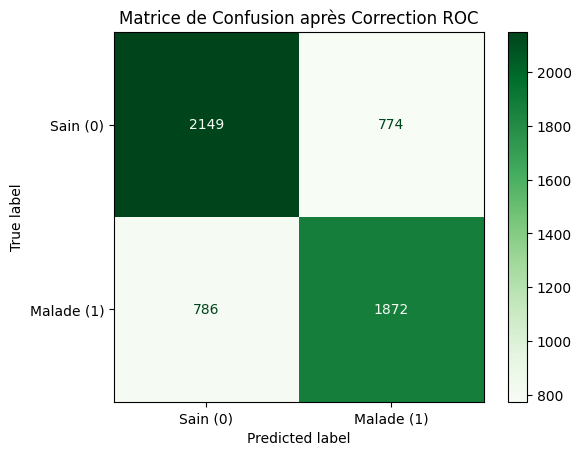

In [10]:
# Configuration des groupes
privileged_groups = [{'Position_Num': 1}]   
unprivileged_groups = [{'Position_Num': 0}] 

# Mise en place de l'algorithme ROC
ROC = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.3,                         # Seuil de classification minimal à tester lors de la recherche
    high_class_thresh=0.7,                        # Seuil de classification maximal à tester lors de la recherche
    num_class_thresh=100,                         # Nombre de seuils à parcourir entre low et high pour la grille
    num_ROC_margin=50,                            # Nombre de marges ROC à tester pour chaque seuil de classification
    metric_name="Statistical parity difference",  # Métrique de fairness à optimiser 
    metric_ub=0.1,                                # Borne supérieure acceptable pour la métrique de fairness
    metric_lb=-0.1                                # Borne inférieure acceptable pour la métrique de fairness
)

# Fit et Predict
ROC = ROC.fit(dataset_true, dataset_pred)       # On calcule le meilleur seuil et la meilleure marge de rejet possible
dataset_transf_pred = ROC.predict(dataset_pred) # Applique la correction d'équité : si la probabilité d'un patient tombe dans la 
                                                # marge de rejet [theta - marge, theta + marge], le modèle "force" l'étiquette :
                                                # - Favorable ('Sain') si le patient est du groupe non-privilégié (AP)
                                                # - Défavorable ('Malade') si le patient est du groupe privilégié (PA)
                                                # En dehors de cette zone, le seuil classique (theta) s'applique normalement.

# Évaluation de la distribution des scores (Diagnostic)
df_base['preds_roc'] = dataset_transf_pred.labels.flatten()
bal_acc = balanced_accuracy_score(df_base['y_true'], df_base['preds_roc'])

print(f"\nDIAGNOSTIC DES SEUILS")
print(f"Seuil final retenu par ROC : {ROC.classification_threshold:.4f}")
print(f"Roc Margin: {ROC.ROC_margin:.4f}")
print(f"Nouvelle Balanced Accuracy : {bal_acc:.4f}")

# Affichage de la confusion matrix
cm_roc = confusion_matrix(df_base['y_true'], df_base['preds_roc'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_roc, display_labels=['Sain (0)', 'Malade (1)'])
disp.plot(cmap='Greens')
plt.title("Matrice de Confusion après Correction ROC")
plt.show()

In [11]:
stats_final = df_base.groupby('View Position')['preds_roc'].mean()

# DI et SPD
di_final = stats_final['PA'] / stats_final['AP'] if stats_final['AP'] != 0 else 0
spd_final = stats_final['PA'] - stats_final['AP']

print(f"BILAN DES SCORES DE FAIRNESS")
print(f"Taux de prédiction 'Malade' AP : {stats_final['AP']*100:.2f}%")
print(f"Taux de prédiction 'Malade' PA : {stats_final['PA']*100:.2f}%")
print(f"Disparate Impact (Cible ~1.0) : {di_final:.4f}")
print(f"Statistical Parity (Cible ~0.0) : {spd_final:.4f}")

BILAN DES SCORES DE FAIRNESS
Taux de prédiction 'Malade' AP : 52.05%
Taux de prédiction 'Malade' PA : 44.00%
Disparate Impact (Cible ~1.0) : 0.8453
Statistical Parity (Cible ~0.0) : -0.0805


---
#### Conclusion : Post-Processing par ROC

L'application de l'algorithme ROC sur nos données de baseline est un succès car il semble que l'on a trouvé un très bon compromis entre **performance** et **fairness**.

Le modèle reste performant avec une *Balanced Accuracy* de **71.97 %**. On peut aussi voir à l'aide de la matrice de confusion qu'il ne répond pas au hasard : il identifie correctement la majorité des patients (2149 sains, 1872 malades), et ses erreurs sont équilibrées (environ autant de fausses alertes que d'oublis).  

En ajustant les diagnostics uniquement lorsque le modèle "hésitait" (autour du seuil de 0.51), le modèle a corrigé ses biais initiaux :
* L'écart de prédiction entre les deux groupes (AP et PA) n'est plus que de 8 % (**SPD = -0.08**).
* Le score de *Disparate Impact* (**DI = 0.84**) dépasse le seuil des 0.80.

**Bilan final :** La méthode ROC a permis de rendre notre modèle de diagnostic juste et non discriminatoire, sans pour autant sacrifier sa précision globale. Cette méthode de post-processing semble donc concluante.

---

### Méthode 2 : Post-processing avec `Calibrated Equalised Odds`(CEO)

L'algorithme `Calibrated Equalised Odds` vise l'égalité des chances. Il ne regarde pas le total, il regarde les erreurs. Son but est de s'assurer que le modèle ne se trompe pas plus sur un groupe que sur un autre (il équilibre les taux de faux positifs et de faux négatifs).

---

RÉSULTATS POST-PROCESSING (CEO)
Balanced Accuracy : 0.6456
Taux 'Malade' AP : 59.99%
Taux 'Malade' PA : 10.02%
Disparate Impact (DI) : 0.1670
Statistical Parity (SPD) : -0.4997


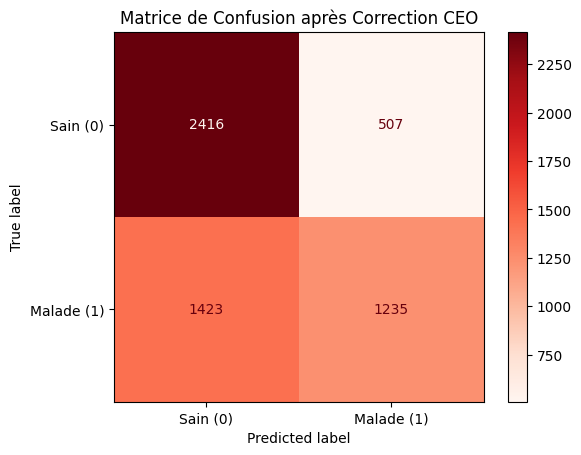

In [12]:
from aif360.algorithms.postprocessing import CalibratedEqOddsPostprocessing

# Configuration des groupes (Pareil que pour la méthode ROC)
privileged_groups = [{'Position_Num': 1}]   
unprivileged_groups = [{'Position_Num': 0}] 

# Mise en place de l'algorithme CEO
# Le paramètre 'cost_constraint' définit quelle erreur est la pire :
# - 'fnr' (False Negative Rate) : C'est pire de rater un malade (Faux Négatif). <- Notre cas (Contexte médical)
CEO = CalibratedEqOddsPostprocessing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    cost_constraint='fnr', 
    seed=42 
)

# Fit et Predict (même logique que pour ROC)
CEO = CEO.fit(dataset_true, dataset_pred)
dataset_transf_pred_ceo = CEO.predict(dataset_pred)

# nouvelles prédictions
df_base['preds_ceo'] = dataset_transf_pred_ceo.labels.flatten()


bal_acc_ceo = balanced_accuracy_score(df_base['y_true'], df_base['preds_ceo'])

# Calcul des métriques par groupe pour le CEO
stats_ceo = df_base.groupby('View Position')['preds_ceo'].mean()
di_ceo = stats_ceo['PA'] / stats_ceo['AP'] if stats_ceo['AP'] != 0 else 0
spd_ceo = stats_ceo['PA'] - stats_ceo['AP']

print(f"RÉSULTATS POST-PROCESSING (CEO)")
print(f"Balanced Accuracy : {bal_acc_ceo:.4f}")
print(f"Taux 'Malade' AP : {stats_ceo['AP']*100:.2f}%")
print(f"Taux 'Malade' PA : {stats_ceo['PA']*100:.2f}%")
print(f"Disparate Impact (DI) : {di_ceo:.4f}")
print(f"Statistical Parity (SPD) : {spd_ceo:.4f}")

# Affichage
cm_ceo = confusion_matrix(df_base['y_true'], df_base['preds_ceo'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ceo, display_labels=['Sain (0)', 'Malade (1)'])
disp.plot(cmap='Reds') # 
plt.title("Matrice de Confusion après Correction CEO")
plt.show()

#### Conclusion : Post-Processing par CEO (Calibrated Equalised Odds)

Contrairement à nos attentes, l'application de l'algorithme CEO sur nos prédictions brutes a fortement dégradé à la fois les performances et l'équité de notre modèle.  

La *Balanced Accuracy* tombe à **64.56 %**. De plus, la matrice de confusion révèle une explosion des "faux négatifs" : **1423** patients réellement malades ont été déclarés sains. Or on sait que dans un contexte médical renvoyer un malade chez lui est la pire chose possible.

En voulant équilibrer les taux d'erreurs au lieu des taux globaux, l'algorithme a créé un déséquilibre massif dans les diagnostics finaux :
* Près de 60 % du groupe AP est diagnostiqué "Malade", contre seulement 10 % du groupe PA. L'écart est immense  avec une *SPD* de **-0.49**.
* Le score de *Disparate Impact* chute à **0.16**, ce qui est extrêmement loin du seuil d'acceptabilité de 0.80. Le modèle est devenu très discriminatoire envers le groupe PA.

---


### Bilan Final : Choix de la méthode de Post-Processing

Evidemment, si l'on devait choisir entre ces 2 méthodes de Post-processing, on prendrait la méthode de `Reject Option Classification`.

* Le CEO a échoué sur nos données : il n'a pas su trouver de compromis et a sacrifié à la fois la sécurité des patients (trop d'oublis) et l'égalité entre les groupes.
* Le ROC a réussi : il a rendu le modèle plus juste pour tout le monde (DI de *0.84*), sans perdre sa capacité à bien détecter la maladie (balanced accuracy de  *72 %*)

Pour notre projet, le post-processing par ROC est donc la solution qu'on retiendra pour rendre notre modèle à la fois performant et juste.

---

## VI - Méthode 3 : Combinaison (Pre + Post)-processing

Dans cette dernière partie, nous analyserons l'efficacité d'une approche combinée en appliquant la méthode de post-processing `Reject Option Classification` effectué à la partie V sur les résultats de notre modèle préalablement entraîné avec la méthode `Reweighing` (pre-processing).  

On ne va pas considérer la méthode de pre-processing de `Scikit-Learn` ni la méthode de post-processing `Calibrated Equalised Odds` au vu de leurs performances insatisfaisantes lors des étapes précédentes.

---


On reprend le même code que celui de la partie V (méthode 1) en l'appliquant au fichier `preds_reweighing.csv`, contenant les prédictions issues du modèle entraîné avec preprocessing via `Reweighing`.

RÉSULTATS COMBINAISON : REWEIGHING + ROC
Balanced Accuracy : 0.6790
Taux 'Malade' AP : 56.32%
Taux 'Malade' PA : 47.60%
Disparate Impact (DI) : 0.8453
Statistical Parity (SPD) : -0.0871


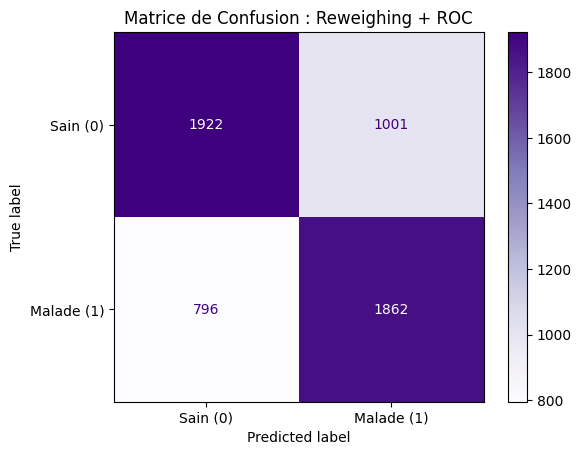

In [13]:
# Chargement des prédictions issues du modèle "Reweighing"
df_reweighing = pd.read_csv("expe_log_reweighing/preds_reweighing.csv") 

# Nettoyage et encodage
df_reweighing['y_true'] = (df_reweighing['labels'] == 'malade').astype(int)
df_reweighing['y_pred_base'] = (df_reweighing['preds'] == 'malade').astype(int)
df_reweighing['Position_Num'] = (df_reweighing['View Position'] == 'PA').astype(int)

# Calcul des probabilités
exp0 = np.exp(df_reweighing['preds_logit0'])
exp1 = np.exp(df_reweighing['preds_logit1'])
df_reweighing['prob_malade'] = exp1 / (exp0 + exp1)

# Dataset pour AIF360
dataset_true_rew = StandardDataset(
    df=df_reweighing,
    label_name='y_true',
    favorable_classes=[0],
    protected_attribute_names=['Position_Num'],
    privileged_classes=[[1]],
    features_to_keep=['prob_malade']
)

dataset_pred_rew = dataset_true_rew.copy()
dataset_pred_rew.labels = df_reweighing['y_pred_base'].values.reshape(-1, 1)
dataset_pred_rew.scores = df_reweighing['prob_malade'].values.reshape(-1, 1)

# Configuration des groupes 
privileged_groups = [{'Position_Num': 1}]
unprivileged_groups = [{'Position_Num': 0}]

# Mise en place de l'algorithme ROC
ROC_combined = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.3,
    high_class_thresh=0.7,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name="Statistical parity difference",
    metric_ub=0.1,
    metric_lb=-0.1
)

# Fit et Transform
ROC_combined = ROC_combined.fit(dataset_true_rew, dataset_pred_rew)
dataset_transf_pred_rew = ROC_combined.predict(dataset_pred_rew)

# Évaluation de la distribution des scores (Diagnostic)
df_reweighing['preds_roc_combined'] = dataset_transf_pred_rew.labels.flatten()
bal_acc_combined = balanced_accuracy_score(df_reweighing['y_true'], df_reweighing['preds_roc_combined'])

stats_comb = df_reweighing.groupby('View Position')['preds_roc_combined'].mean()
di_comb = stats_comb['PA'] / stats_comb['AP'] if stats_comb['AP'] != 0 else 0
spd_comb = stats_comb['PA'] - stats_comb['AP']

print(f"RÉSULTATS COMBINAISON : REWEIGHING + ROC")
print(f"Balanced Accuracy : {bal_acc_combined:.4f}")
print(f"Taux 'Malade' AP : {stats_comb['AP']*100:.2f}%")
print(f"Taux 'Malade' PA : {stats_comb['PA']*100:.2f}%")
print(f"Disparate Impact (DI) : {di_comb:.4f}")
print(f"Statistical Parity (SPD) : {spd_comb:.4f}")

# Affichage
cm_comb = confusion_matrix(df_reweighing['y_true'], df_reweighing['preds_roc_combined'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_comb, display_labels=['Sain (0)', 'Malade (1)'])
disp.plot(cmap='Purples') 
plt.title("Matrice de Confusion : Reweighing + ROC")
plt.show()

### Conclusion : Combinaison Reweighing (Pre) + ROC (Post)

On s'aperçoit que combiner les deux méthodes n'améliore pas notre modèle, bien au contraire. L'application du pre-processing a perturbé la distribution naturelle des probabilités, rendant le travail de correction du post-processing moins précis.


La *Balanced Accuracy* chute à **67.90 %** (contre **71.97 %** pour le ROC seul). La matrice de confusion montre que le modèle fait plus d'erreurs dans les deux sens : il détecte moins bien les malades réels (1759 vrais positifs contre 1872 avant) et diagnostique plus souvent des patients sains comme malades (890 faux positifs contre 774 avant).

En revanche, les critères d'équité restent parfaitement respectés : l'écart entre les groupes est faible (**SPD = -0.08**) et le *Disparate Impact* est validé (**DI = 0.84**). Cependant, ces scores ne sont pas meilleurs que ceux obtenus avec l'algorithme ROC utilisé seul. L'ajout du `Reweighing` n'a donc apporté aucun bénéfice éthique supplémentaire.

---


## VII. Conclusion

Au terme de toutes nos expérimentations, la méthode de Post-Processing par ROC (`Reject Option Classification`) appliquée sur le modèle de base (`Baseline`) est désignée comme la solution optimale. C'est la seule méthode qui a réussi à rendre notre modèle juste et équitable, sans lui faire perdre sa précision médicale.  

En effet, les autres approches testées (comme le pre-processing par `Reweighing` ou le post-processing par `Calibrated Equalised Odds`) ont montré que vouloir trop corriger le modèle le rend moins performant, ce qui augmente le risque de rater des patients vraiment malades.

En résumé, ce projet prouve qu'il est tout à fait possible de créer un modèle d'intelligence artificielle médicale sans biais (ou presque). La solution n'est pas de transformer toutes les données, mais juste de corriger l'algorithme lorsqu'il hésite. Avec la méthode ROC, nous avons obtenu le résultat attendu : un outil de diagnostic fiable pour les médecins et juste pour tous les patients.

